In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

from src.data_preprocessing import (
    read_oscilloscope_data, 
    segment_signal,
    perform_fft_on_segments,
    plot_random_segments,
    plot_manual_fft_as_full_spectrogram,
    plot_full_scipy_spectrogram,
    plot_spectrogram_samples,
    spectrogram_samples_from_file,
    spectrogram_samples_manual,
    spectrogram_samples_using_scipy,
    numpy_to_pillow,
    scipy_to_pillow
)

Считаем сигнал из файла.

In [27]:
df = read_oscilloscope_data(
    file_path='../data/raw/0702 без перекосов фаза A.txt',
    output_path='../data/processed/Anomalous.csv'
    )

healthy_signal = df['Data'].to_numpy()
healthy_signal_mean = np.mean(healthy_signal)
healthy_signal -= healthy_signal_mean

Отрисуем часть сигнала.

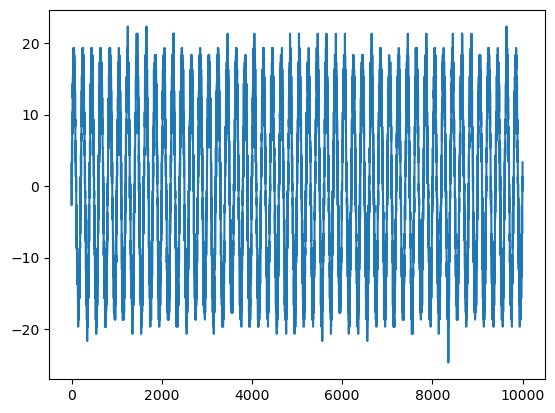

In [28]:
n = 10000
plt.plot(list(range(n)), healthy_signal[:n])
plt.show()

In [29]:
segments = segment_signal(healthy_signal, segment_length=10000, step=20, apply_window='blackman')

Случайные сегменты сигнала после применения оконной функции.

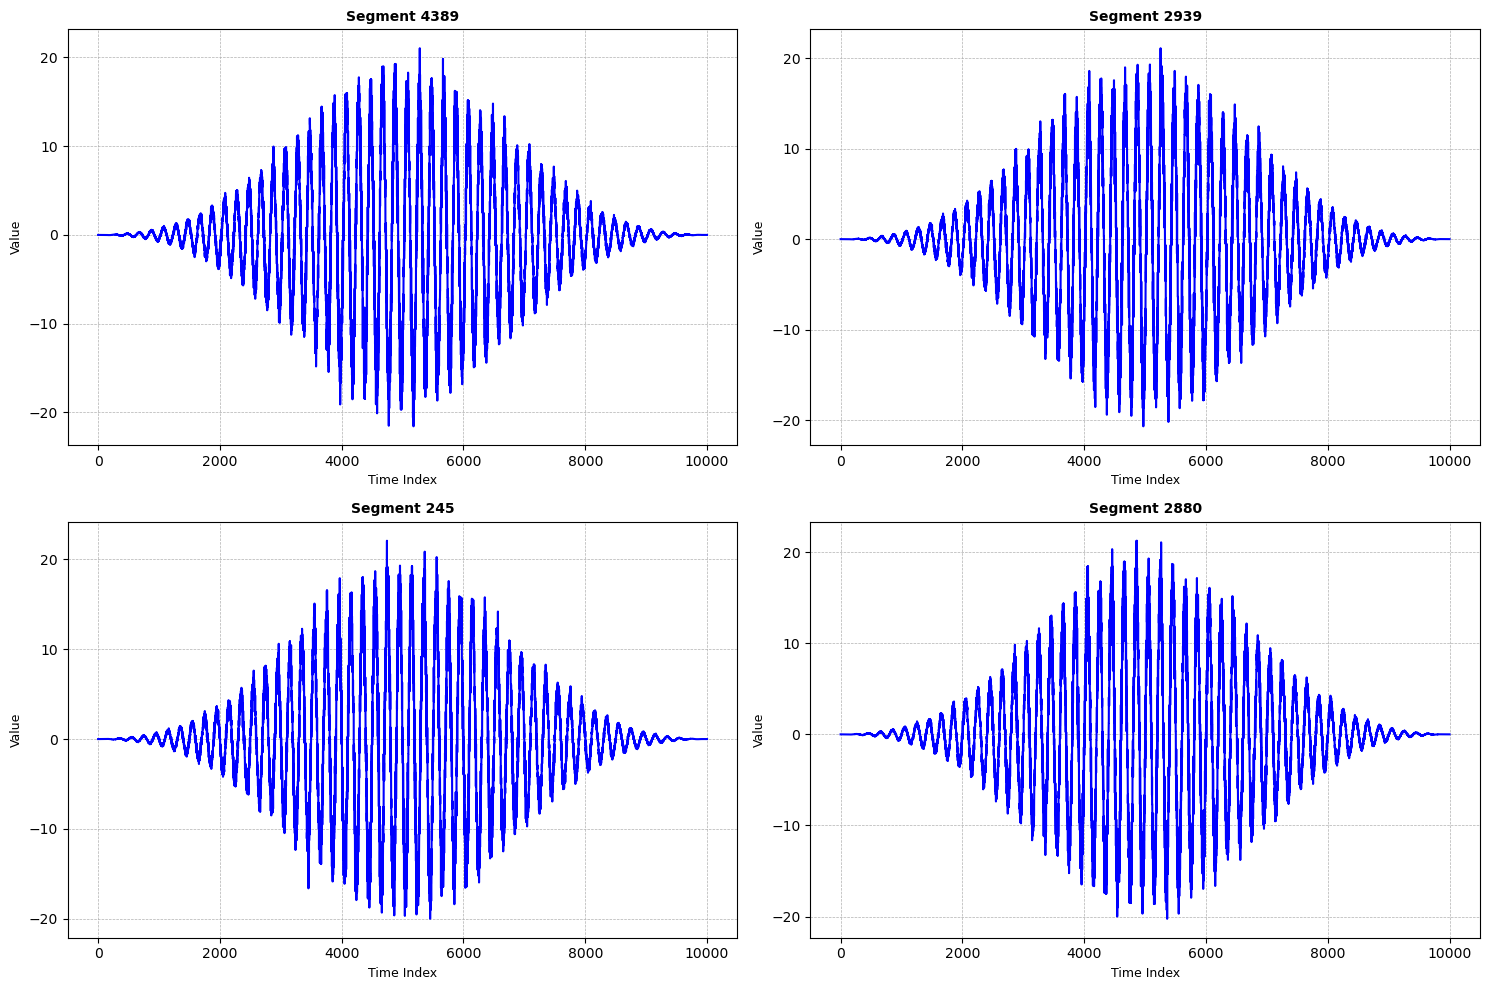

In [30]:
plot_random_segments(segments, num_segments=4, max_points=None, axis_labels=('Time Index', 'Value'))
plt.show()

In [31]:
fft_segments, freqs = perform_fft_on_segments(segments, f_sampling=10000, db=True, cutoff_freq=250)

In [32]:
def plot_single_segment_with_uncertainty(fft_segments, x_values=None, max_points=1000, n_std=2, title="Spectrum with Uncertainty",
                                         axis_labels=None, highlight_freqs=None, method='closest'):
    spectrum_mean = np.mean(fft_segments, axis=0)
    spectrum_std = np.std(fft_segments, axis=0) * n_std 

    if max_points is not None and len(spectrum_mean) > max_points:
        spectrum_mean = signal.resample(spectrum_mean, max_points)
        spectrum_std = signal.resample(spectrum_std, max_points)
        if x_values is not None:
            if len(x_values.shape) == 1:
                x_values = signal.resample(x_values, max_points)
            else:
                x_values = signal.resample(x_values, max_points)
        else:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))
    else:
        if x_values is None:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))

    x_label, y_label = axis_labels if axis_labels else ('Frequency, Hz', 'Power, dB')
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_values, spectrum_mean, linewidth=2.0, color='blue', label='Mean Spectrum')
    ax.fill_between(
        x_values,
        spectrum_mean - spectrum_std,
        spectrum_mean + spectrum_std,
        color='blue',
        alpha=0.2,
        label=f'Uncertainty (±{n_std} SD)'
    )

    ax.plot(x_values, spectrum_mean - spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    ax.plot(x_values, spectrum_mean + spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    
    if highlight_freqs is not None and len(highlight_freqs) > 0:
        for freq in highlight_freqs:
            if method == 'closest':
                closest_idx = np.abs(x_values - freq).argmin()
                ax.scatter(x_values[closest_idx], spectrum_mean[closest_idx], color='red', s=50)
    
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel(y_label, fontsize=9)
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    return fig, ax

Усредненный спектр.

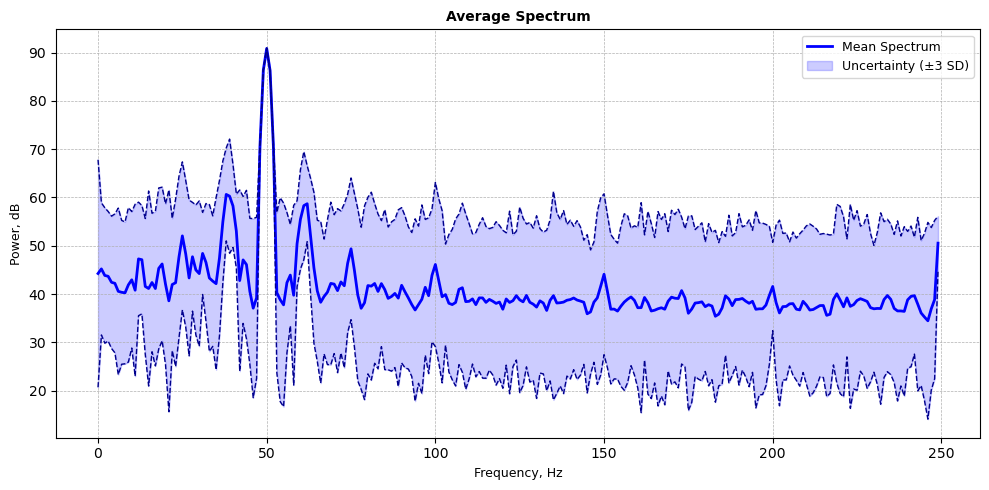

In [33]:
plot_single_segment_with_uncertainty(fft_segments, x_values=freqs, n_std=3, title='Average Spectrum')
plt.show()

Преобразуем полученные FFT-сегменты в спектрограмму.

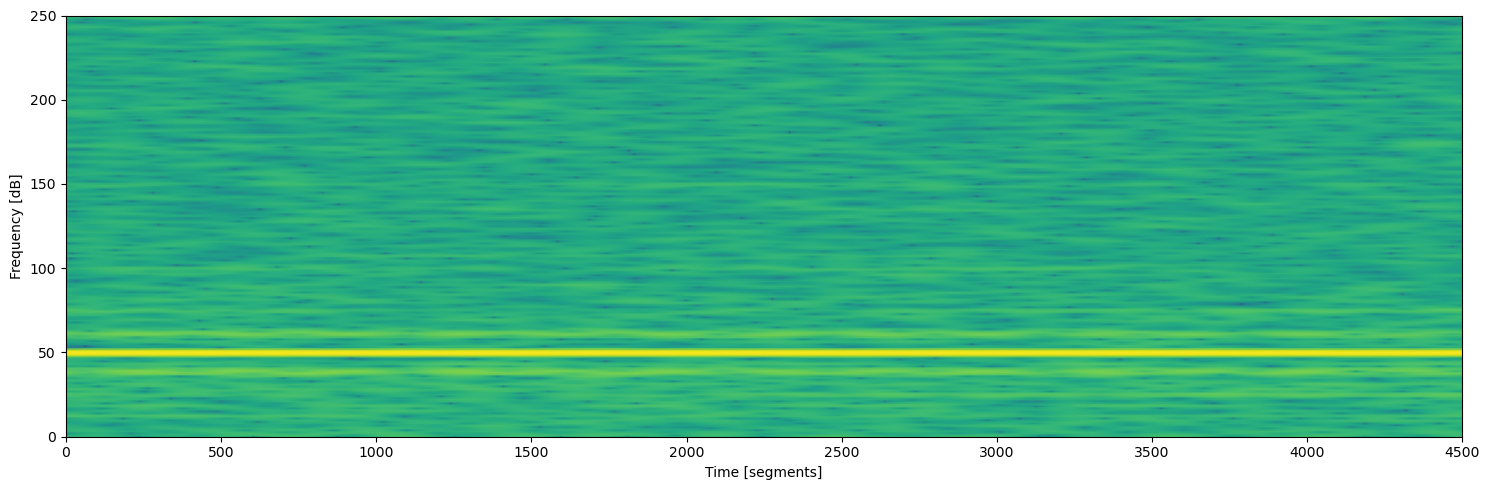

In [34]:
plot_manual_fft_as_full_spectrogram(fft_segments, freqs)

Сравним со спектрограммой, полученной при помощи scipy.signal.spectrogram.

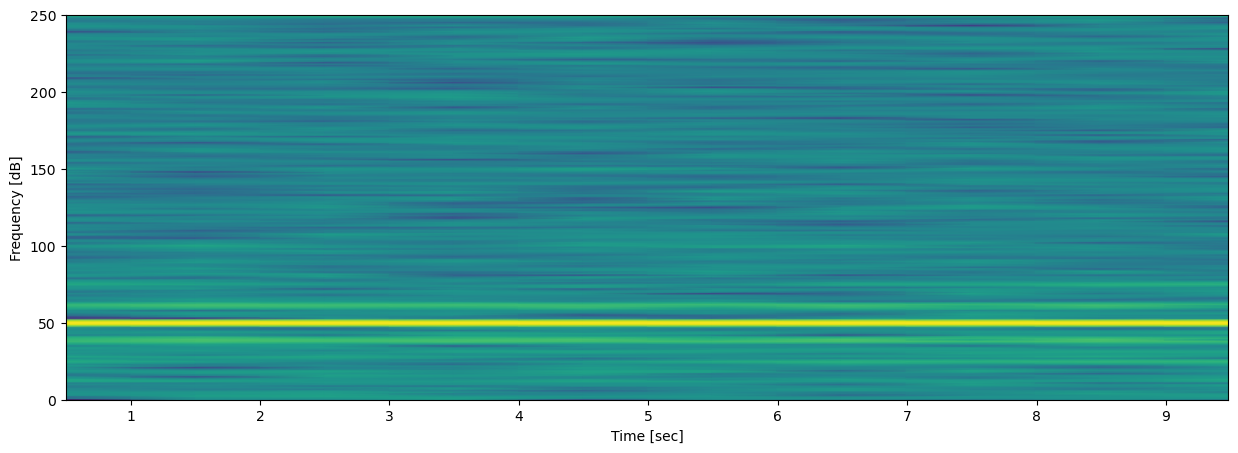

In [35]:
plot_full_scipy_spectrogram(healthy_signal)

Спектрограммы случайных сегментов сигнала заданной длины.

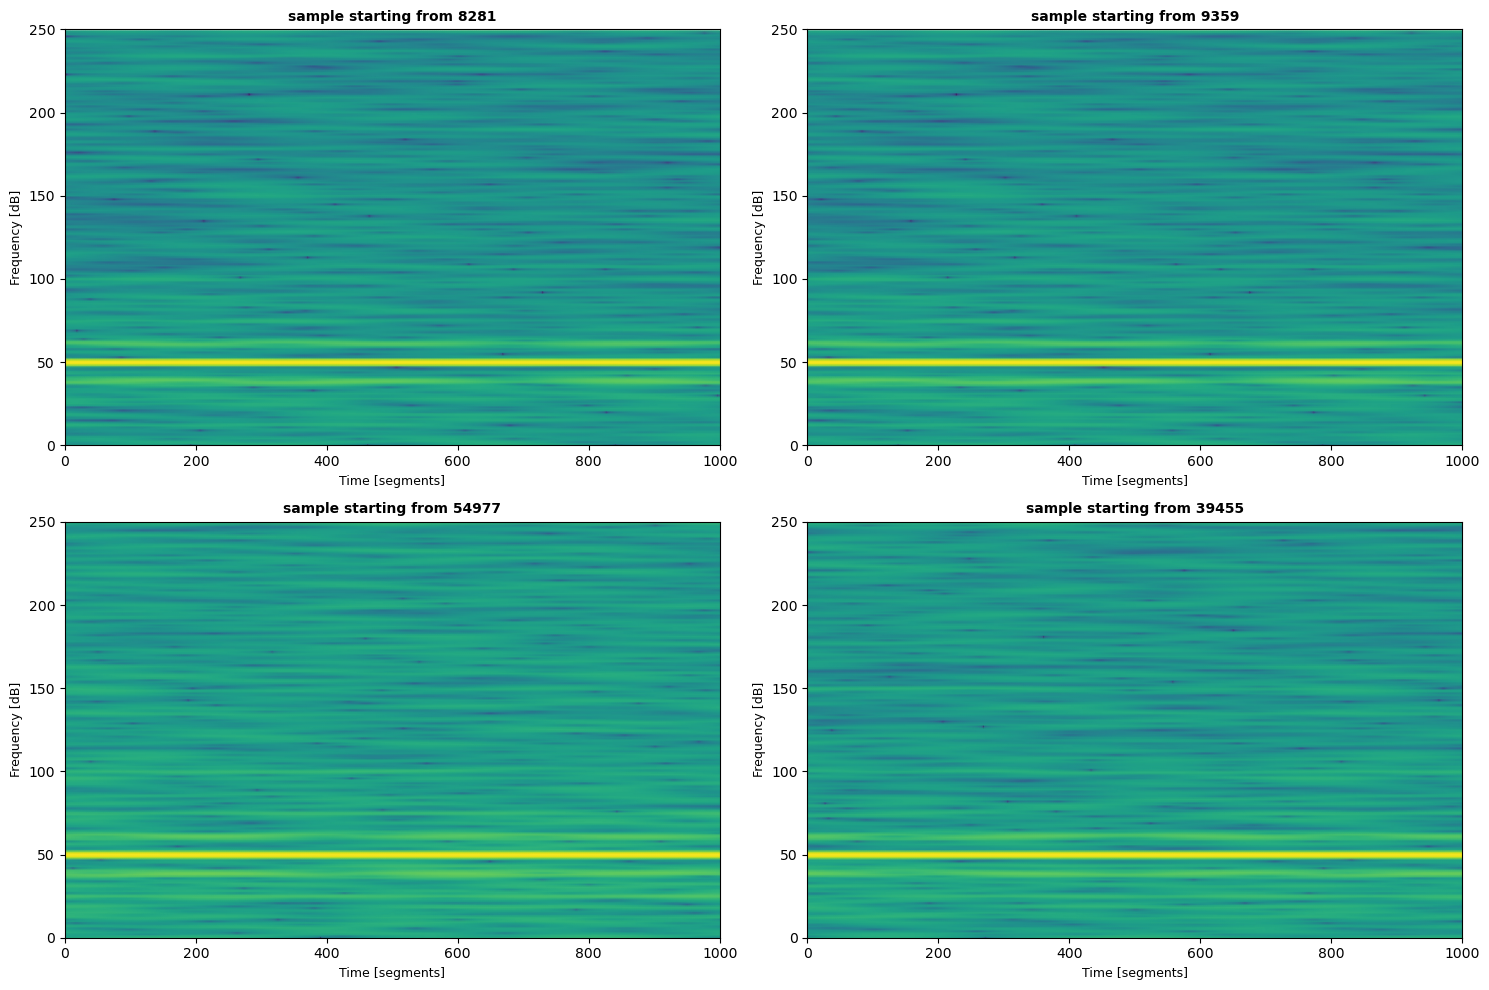

In [36]:
signal_samples = spectrogram_samples_manual(healthy_signal, 3, 4)
plot_spectrogram_samples(signal_samples, ('Time [segments]', 'Frequency [dB]'))
plt.show()

Считаем еще один сигнал из файла.

In [37]:
df = read_oscilloscope_data(
    file_path='../data/raw/0702  межвитковые фазы A ток фазы А.txt',
    output_path='../data/processed/Anomalous.csv'
    )

fault_signal = df['Data'].to_numpy()
fault_signal_mean = np.mean(fault_signal)
fault_signal -= fault_signal_mean

In [38]:
segments = segment_signal(fault_signal, segment_length=10000, step=20, apply_window='blackman')

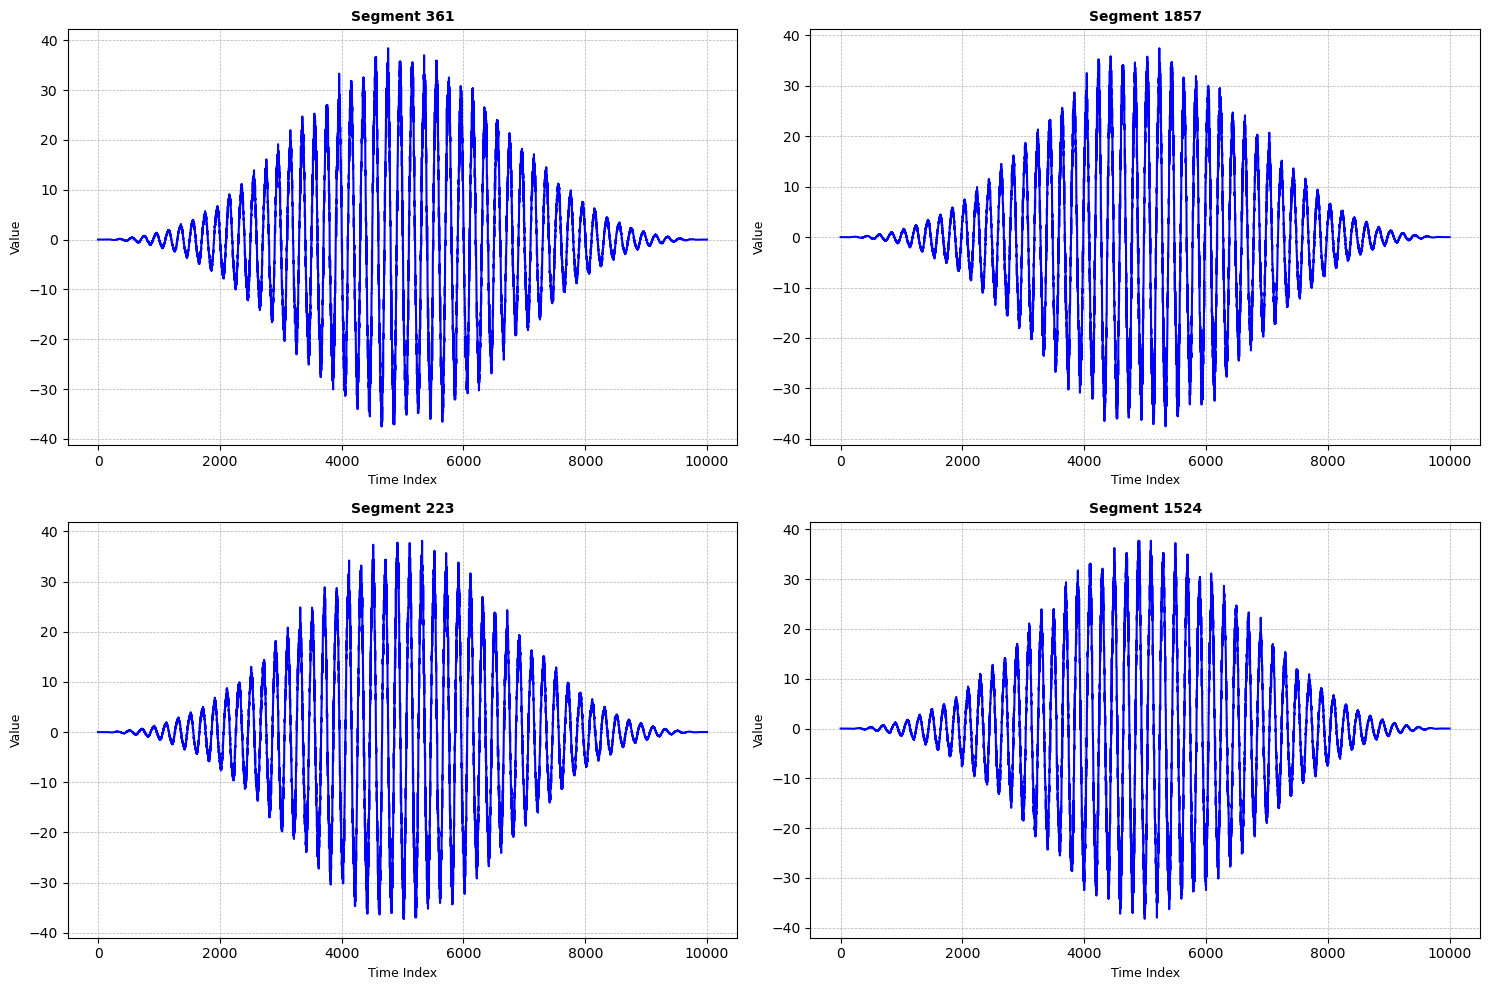

In [39]:
plot_random_segments(segments, num_segments=4, max_points=None, axis_labels=('Time Index', 'Value'))
plt.show()

In [40]:
fft_segments, freqs = perform_fft_on_segments(segments, f_sampling=10000, db=True, cutoff_freq=250)

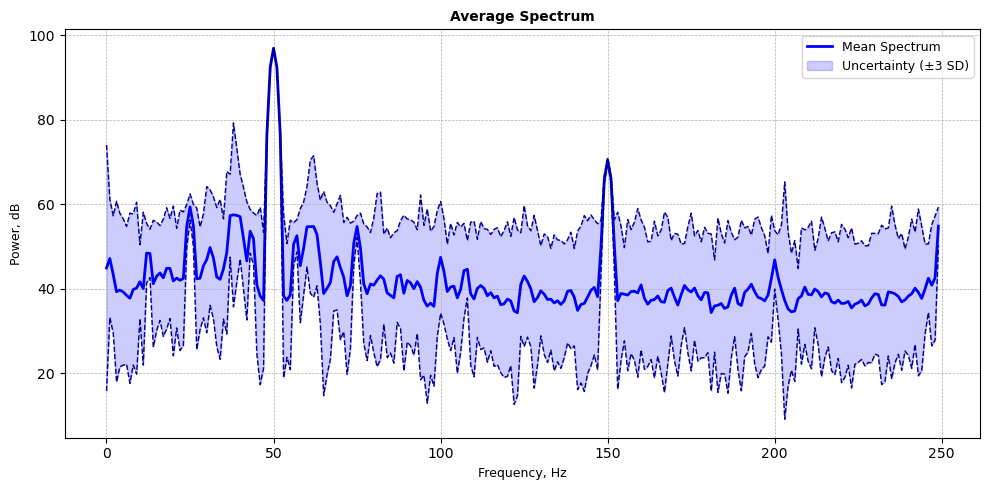

In [41]:
plot_single_segment_with_uncertainty(fft_segments, x_values=freqs, n_std=3, title='Average Spectrum')
plt.show()

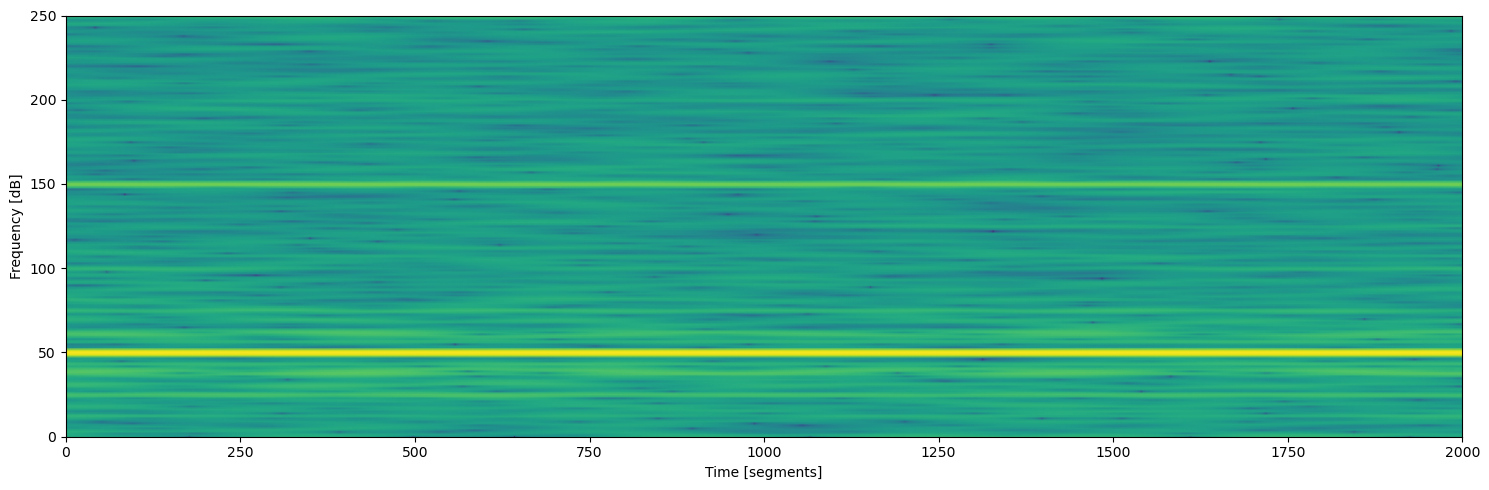

In [42]:
plot_manual_fft_as_full_spectrogram(fft_segments, freqs)

Функции сохранения спектрограммы в качестве картинки.

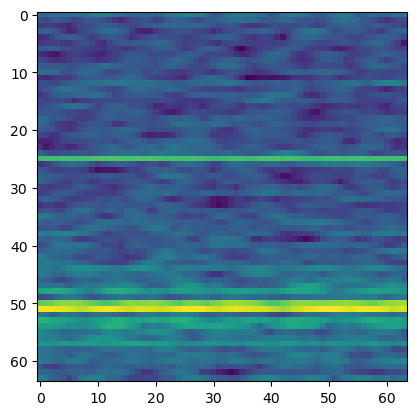

In [43]:
img = numpy_to_pillow(fft_segments.T)
plt.imshow(img)

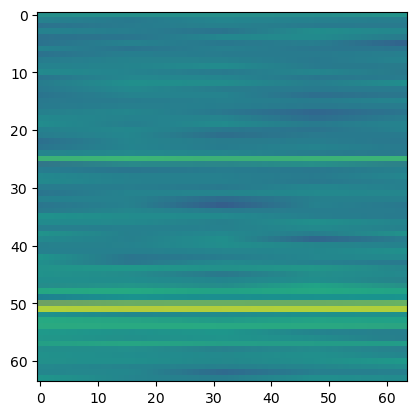

In [44]:
f, t, Sxx = signal.spectrogram(fault_signal, fs=10000, nperseg=10000, window='blackman', noverlap=20)
img = scipy_to_pillow(f, t, Sxx)
plt.imshow(img, cmap='gray')